<a href="https://colab.research.google.com/github/kawishx/Diabetic-Retinopathy-Detection/blob/main/Diabetic_Retinopathy_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Drive and install required dependencies

**Import PyTorch and Check version and GPU**

In [1]:
import os
import torch

print(f"PyTorch Version: {torch.__version__}")

# Verify that GPU acceleration is active
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"Device Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device("cpu")
    print("WARNING: CUDA is not active. Go to Runtime > Change runtime type and select T4 GPU.")

PyTorch Version: 2.11.0+cu128
GPU Available: Tesla T4
Device Memory: 15.64 GB


**Import the datase from Kagglehub**

In [2]:
import os
import glob
import pandas as pd
import kagglehub

# 1. Download the complete dataset directory (images + annotations)
dataset_path = kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-gaussian-filtered")
print("Dataset downloaded successfully to path:", dataset_path)

# 2. Check the directory structure
print("\nTop-level contents:")
for item in os.listdir(dataset_path):
    print(" -", item)

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-gaussian-filtered' dataset.
Dataset downloaded successfully to path: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered

Top-level contents:
 - gaussian_filtered_images
 - train.csv


**Check for data inside the dataset**

In [3]:
# Check for CSV or class folders
csv_path = os.path.join(dataset_path, "train.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("\nFound train.csv:")
    print(df.head())
    print("\nClass distribution in CSV:")
    print(df['diagnosis'].value_counts().sort_index())
else:
    # If organized purely by subfolders:
    print("\nScanning class subfolders:")
    for root, dirs, files in os.walk(dataset_path):
        if files and any(f.endswith(('.png', '.jpg', '.jpeg')) for f in files):
            folder_name = os.path.basename(root)
            print(f"Folder '{folder_name}': {len(files)} images")


Found train.csv:
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Class distribution in CSV:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


**Map Image Paths and Distribution Figure**

Total image files located: 3662
Verified images matched to labels: 3662/3662


/tmp/ipykernel_2334/3596613181.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='stage_name', order=list(class_names.values()), palette=palette)


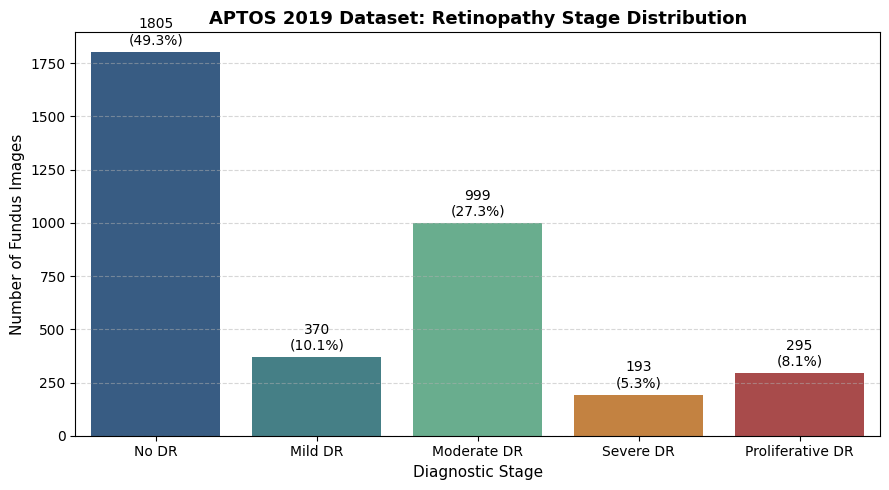

Saved figure1_class_distribution.png successfully.


In [4]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map stage numbers to clinical descriptions
class_names = {
    0: 'No DR',
    1: 'Mild DR',
    2: 'Moderate DR',
    3: 'Severe DR',
    4: 'Proliferative DR'
}
df['stage_name'] = df['diagnosis'].map(class_names)

# 2. Locate the image files
all_image_paths = glob.glob(f"{dataset_path}/**/*.png", recursive=True)
if not all_image_paths:
    all_image_paths = glob.glob(f"{dataset_path}/**/*.jpg", recursive=True)

print(f"Total image files located: {len(all_image_paths)}")

# Build a lookup dictionary: {filename_without_ext: full_path}
path_lookup = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}
df['file_path'] = df['id_code'].map(path_lookup)

# Drop any rows where image file is missing (if any)
missing_count = df['file_path'].isna().sum()
print(f"Verified images matched to labels: {len(df) - missing_count}/{len(df)}")

# 3. Generate Figure 1: Class Distribution
plt.figure(figsize=(9, 5))
palette = ["#2b5c8f", "#3a8891", "#5eb88f", "#d9822b", "#b83b3b"]
ax = sns.countplot(data=df, x='stage_name', order=list(class_names.values()), palette=palette)

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f"{100 * count / total:.1f}%"
    ax.annotate(f"{count}\n({percentage})",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.title("APTOS 2019 Dataset: Retinopathy Stage Distribution", fontsize=13, weight='bold')
plt.xlabel("Diagnostic Stage", fontsize=11)
plt.ylabel("Number of Fundus Images", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save image to disk for your PDF report
plt.savefig("figure1_class_distribution.png", dpi=300)
plt.show()
print("Saved figure1_class_distribution.png successfully.")

**Implement Ben Graham's Preprocessing Pipeline**

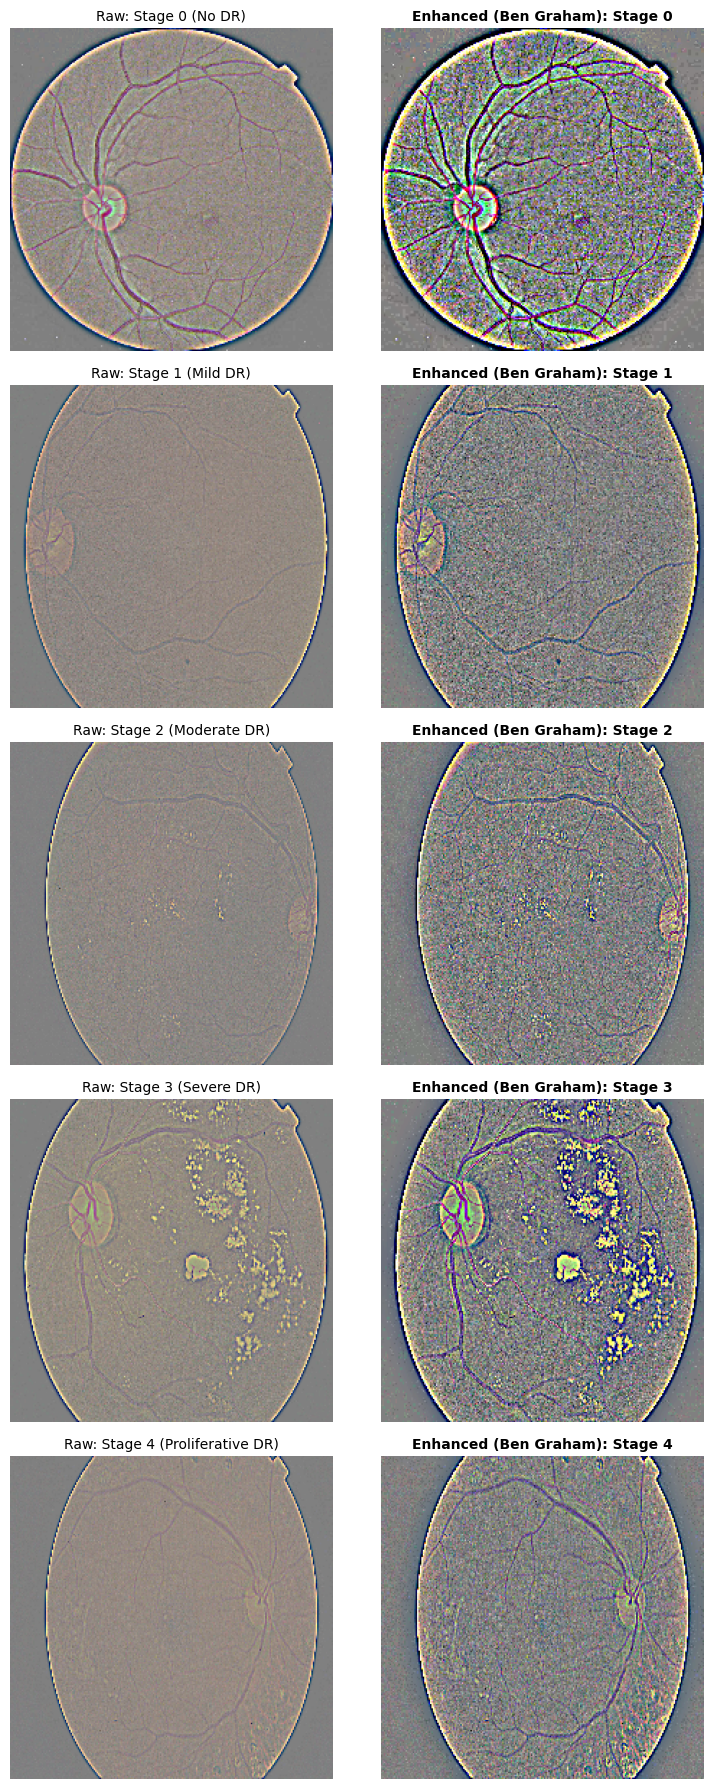

Saved figure2_preprocessing_comparison.png successfully.


In [5]:
import cv2
import numpy as np

def crop_fundus_circle(image, tolerance=7):
    """Crops empty black margins around circular retinal fundus images."""
    if image.ndim == 2:
        mask = image > tolerance
        return image[np.ix_(mask.any(1), mask.any(0))]

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    mask = gray > tolerance

    # Check if image has content
    if not np.any(mask):
        return image

    check_shape = image[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]
    if check_shape == 0:
        return image

    img1 = image[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
    img2 = image[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
    img3 = image[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
    return np.stack([img1, img2, img3], axis=-1)

def ben_graham_preprocessing(image_path, target_size=(224, 224), sigma_x=10):
    """
    Applies circular cropping, resizing, and Ben Graham's local contrast enhancement.
    """
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 1. Circular Crop
    image = crop_fundus_circle(image)

    # 2. Resize
    image = cv2.resize(image, target_size)

    # 3. Gaussian Local Contrast Enhancement
    # Formula: 4*image - 4*gaussian_blur + 128
    blurred = cv2.GaussianBlur(image, (0, 0), sigma_x)
    enhanced = cv2.addWeighted(image, 4, blurred, -4, 128)

    return enhanced

# -------------------------------------------------------------
# Generate Figure 2: Visual Comparison (Raw vs Preprocessed)
# -------------------------------------------------------------
fig, axes = plt.subplots(5, 2, figsize=(8, 18))

for stage in range(5):
    sample = df[df['diagnosis'] == stage].iloc[0]
    raw_img = cv2.imread(sample['file_path'])
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    processed_img = ben_graham_preprocessing(sample['file_path'])

    # Raw Image Column
    axes[stage, 0].imshow(cv2.resize(raw_img, (224, 224)))
    axes[stage, 0].set_title(f"Raw: Stage {stage} ({class_names[stage]})", fontsize=10)
    axes[stage, 0].axis('off')

    # Preprocessed Column
    axes[stage, 1].imshow(processed_img)
    axes[stage, 1].set_title(f"Enhanced (Ben Graham): Stage {stage}", fontsize=10, weight='bold')
    axes[stage, 1].axis('off')

plt.tight_layout()
plt.savefig("figure2_preprocessing_comparison.png", dpi=300)
plt.show()
print("Saved figure2_preprocessing_comparison.png successfully.")

**Dataset Splitting and weighting**

In [6]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# 1. Clean missing file rows if any exist
clean_df = df.dropna(subset=['file_path']).reset_index(drop=True)

# 2. Stratified 70% Train, 15% Validation, 15% Test split
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    random_state=42,
    stratify=clean_df['diagnosis']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['diagnosis']
)

print(f"Dataset Split Completed:")
print(f" - Training Set:   {len(train_df)} images ({len(train_df)/len(clean_df)*100:.1f}%)")
print(f" - Validation Set: {len(val_df)} images ({len(val_df)/len(clean_df)*100:.1f}%)")
print(f" - Test Set:       {len(test_df)} images ({len(test_df)/len(clean_df)*100:.1f}%)")

# 3. Calculate balanced class weights for training
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("\nComputed Class Weights (to penalize minority misclassifications):")
for idx, weight in enumerate(class_weights):
    print(f" - Stage {idx} ({class_names[idx]}): {weight:.3f}")

Dataset Split Completed:
 - Training Set:   2563 images (70.0%)
 - Validation Set: 549 images (15.0%)
 - Test Set:       550 images (15.0%)

Computed Class Weights (to penalize minority misclassifications):
 - Stage 0 (No DR): 0.406
 - Stage 1 (Mild DR): 1.979
 - Stage 2 (Moderate DR): 0.733
 - Stage 3 (Severe DR): 3.797
 - Stage 4 (Proliferative DR): 2.476


**PyTorch Dataset Class and Transforms Pipeline**

In [7]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Standard ImageNet mean and standard deviation for pre-trained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# 1. Augmentation pipeline for training set
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=360),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1), shear=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 2. Deterministic pipeline for validation and testing (no random alterations)
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 3. Custom PyTorch Dataset Loader
class RetinopathyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'file_path']
        label = self.df.loc[idx, 'diagnosis']

        # Load image via PIL
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# 4. Instantiate PyTorch Datasets
train_dataset = RetinopathyDataset(train_df, transform=train_transforms)
val_dataset   = RetinopathyDataset(val_df, transform=eval_transforms)
test_dataset  = RetinopathyDataset(test_df, transform=eval_transforms)

# 5. Build DataLoaders (batch size 32 optimizes T4 GPU memory)
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("DataLoaders successfully configured:")
print(f" - Train Batches: {len(train_loader)} | Val Batches: {len(val_loader)} | Test Batches: {len(test_loader)}")

DataLoaders successfully configured:
 - Train Batches: 81 | Val Batches: 18 | Test Batches: 18


**Visualize Data Augmentations**

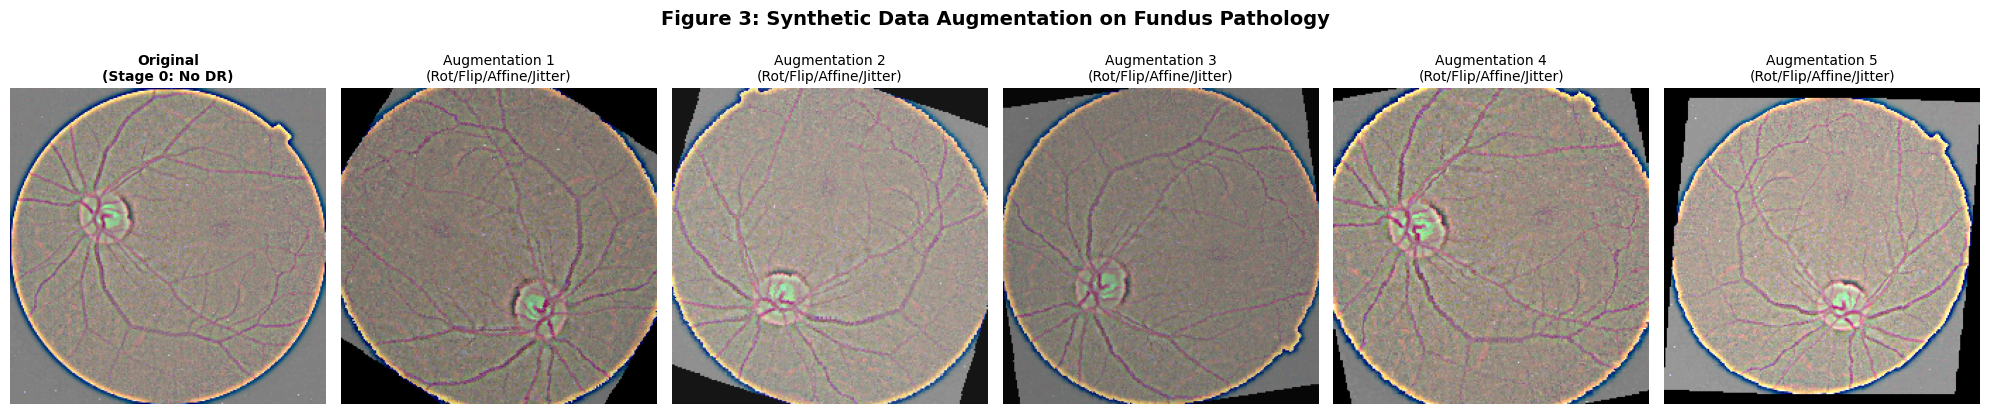

Saved figure3_data_augmentation.png successfully.


In [8]:
import matplotlib.pyplot as plt

# Retrieve one sample image
sample_row = train_df.iloc[10]
sample_pil = Image.open(sample_row['file_path']).convert("RGB")

# Pipeline without normalization (for natural RGB rendering)
viz_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=360),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1), shear=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

fig, axes = plt.subplots(1, 6, figsize=(20, 4))

# Original un-augmented image
axes[0].imshow(sample_pil.resize((224, 224)))
axes[0].set_title(f"Original\n(Stage {sample_row['diagnosis']}: {sample_row['stage_name']})", fontsize=10, weight='bold')
axes[0].axis('off')

# 5 random stochastic augmentations
for i in range(1, 6):
    aug_img = viz_transform(sample_pil)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmentation {i}\n(Rot/Flip/Affine/Jitter)", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Figure 3: Synthetic Data Augmentation on Fundus Pathology", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.savefig("figure3_data_augmentation.png", dpi=300)
plt.show()
print("Saved figure3_data_augmentation.png successfully.")

In [9]:
import torch
import torch.nn as nn
from torchvision import models

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing model pipeline on device: {device}")

def build_retinopathy_model(num_classes=5, dropout_rate=0.4):
    """
    Constructs an EfficientNet-B3 backbone pre-trained on ImageNet
    with a customized medical classification head.
    """
    # 1. Load pre-trained EfficientNet-B3 weights
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

    # 2. Extract incoming feature dimensions from original classifier
    in_features = model.classifier[1].in_features

    # 3. Replace default classifier head with regularized dense network
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.Mish(),  # Smooth, non-monotonic activation function
        nn.Dropout(p=dropout_rate / 2),
        nn.Linear(512, num_classes)
    )

    return model

# Instantiate and verify structure
model = build_retinopathy_model(num_classes=5).to(device)
print(f"Model successfully loaded. Classification head:\n{model.classifier}")

Executing model pipeline on device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 126MB/s]


Model successfully loaded. Classification head:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1536, out_features=512, bias=True)
  (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Mish()
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=512, out_features=5, bias=True)
)


In [10]:
import copy
import time

# 1. Class-weighted Cross-Entropy Loss to counter dataset imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

# 2. Early Stopping and Model Checkpoint class
class EarlyStoppingCheckpoint:
    def __init__(self, patience=4, min_delta=0.001, save_path="best_retinopathy_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"  [+] Validation loss improved. Checkpoint saved to {self.save_path}")
        else:
            self.counter += 1
            print(f"  [-] Validation loss did not improve. EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

**Module Training & Evaluation Loop**

In [11]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += labels.size(0)

    return running_loss / total, correct / total

**Model Training and Fine Tuning**

In [12]:
# Initialize metrics tracking dictionary
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': []
}

# -------------------------------------------------------------
# PHASE 1: Classifier Warm-Up (Backbone Frozen)
# -------------------------------------------------------------
print("=== Starting Phase 1: Classifier Head Warm-Up (3 Epochs) ===")
# Freeze backbone feature extractors
for param in model.features.parameters():
    param.requires_grad = False

optimizer_warmup = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 4):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_warmup, device)
    vl_loss, vl_acc = evaluate_model(model, val_loader, criterion, device)

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);     history['val_acc'].append(vl_acc)

    print(f"Warm-Up Epoch {epoch}/3 | Train Loss: {tr_loss:.4f}, Acc: {tr_acc*100:.2f}% | Val Loss: {vl_loss:.4f}, Acc: {vl_acc*100:.2f}% | Time: {time.time()-t0:.1f}s")

# -------------------------------------------------------------
# PHASE 2: End-to-End Fine-Tuning (Backbone Unfrozen)
# -------------------------------------------------------------
print("\n=== Starting Phase 2: Full Network Fine-Tuning ===")
# Unfreeze all layers for subtle adaptation
for param in model.parameters():
    param.requires_grad = True

FINE_TUNE_EPOCHS = 10
optimizer_finetune = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_finetune, T_max=FINE_TUNE_EPOCHS, eta_min=1e-6)
early_stopping = EarlyStoppingCheckpoint(patience=4, save_path="best_retinopathy_model.pth")

for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_finetune, device)
    vl_loss, vl_acc = evaluate_model(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);     history['val_acc'].append(vl_acc)

    print(f"Fine-Tune Epoch {epoch}/{FINE_TUNE_EPOCHS} | Train Loss: {tr_loss:.4f}, Acc: {tr_acc*100:.2f}% | Val Loss: {vl_loss:.4f}, Acc: {vl_acc*100:.2f}% | Time: {time.time()-t0:.1f}s")

    early_stopping.step(vl_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered. Training terminated.")
        break

# Load weights from the best performing validation epoch
model.load_state_dict(torch.load("best_retinopathy_model.pth"))
print("\nLoaded optimal model checkpoint from best_retinopathy_model.pth.")

=== Starting Phase 1: Classifier Head Warm-Up (3 Epochs) ===
Warm-Up Epoch 1/3 | Train Loss: 1.4155, Acc: 54.90% | Val Loss: 1.4768, Acc: 60.29% | Time: 20.6s
Warm-Up Epoch 2/3 | Train Loss: 1.2552, Acc: 59.19% | Val Loss: 1.2494, Acc: 55.92% | Time: 16.1s
Warm-Up Epoch 3/3 | Train Loss: 1.2034, Acc: 60.91% | Val Loss: 1.1739, Acc: 62.48% | Time: 15.9s

=== Starting Phase 2: Full Network Fine-Tuning ===
Fine-Tune Epoch 1/10 | Train Loss: 1.0967, Acc: 65.04% | Val Loss: 1.0771, Acc: 62.66% | Time: 31.5s
  [+] Validation loss improved. Checkpoint saved to best_retinopathy_model.pth
Fine-Tune Epoch 2/10 | Train Loss: 1.0465, Acc: 67.42% | Val Loss: 1.0428, Acc: 63.93% | Time: 30.4s
  [+] Validation loss improved. Checkpoint saved to best_retinopathy_model.pth
Fine-Tune Epoch 3/10 | Train Loss: 0.9900, Acc: 68.67% | Val Loss: 1.0250, Acc: 66.12% | Time: 29.9s
  [+] Validation loss improved. Checkpoint saved to best_retinopathy_model.pth
Fine-Tune Epoch 4/10 | Train Loss: 0.9058, Acc: 71.44

**Plot Training & Validation Curves**

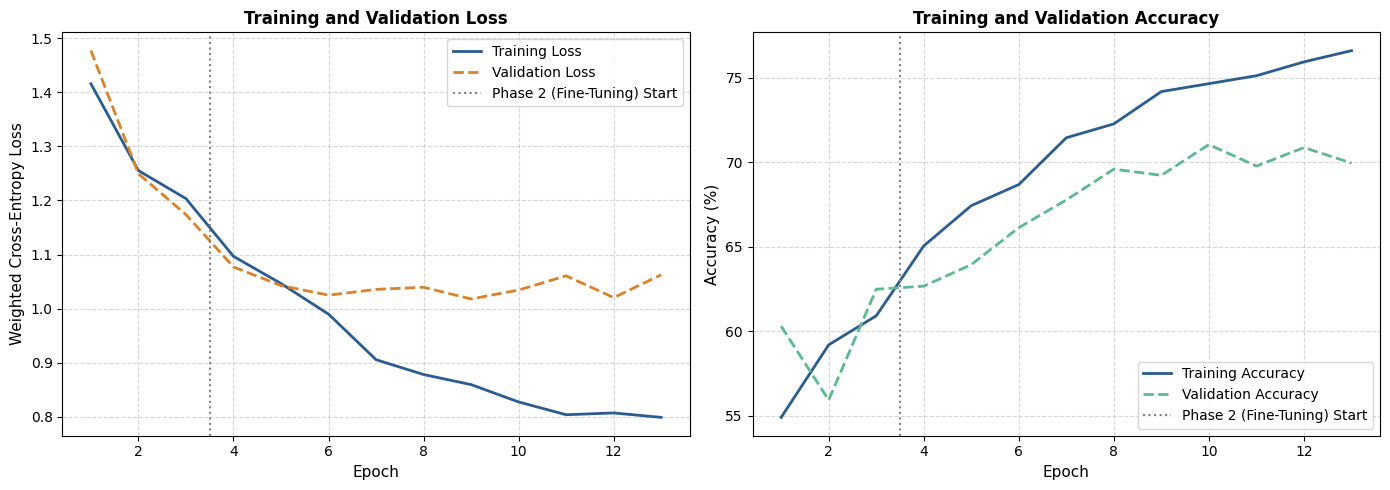

Saved figure4_training_curves.png successfully.


In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Subplot 1: Cross-Entropy Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='#2b5c8f', lw=2)
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='#d9822b', lw=2, linestyle='--')
plt.axvline(x=3.5, color='gray', linestyle=':', label='Phase 2 (Fine-Tuning) Start')
plt.title('Training and Validation Loss', fontsize=12, weight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Weighted Cross-Entropy Loss', fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history['train_acc']], label='Training Accuracy', color='#2b5c8f', lw=2)
plt.plot(epochs_range, [acc * 100 for acc in history['val_acc']], label='Validation Accuracy', color='#5eb88f', lw=2, linestyle='--')
plt.axvline(x=3.5, color='gray', linestyle=':', label='Phase 2 (Fine-Tuning) Start')
plt.title('Training and Validation Accuracy', fontsize=12, weight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figure4_training_curves.png', dpi=300)
plt.show()
print("Saved figure4_training_curves.png successfully.")

**Metrics & COnfusion Mrix**


TEST SET CLASSIFICATION REPORT
                            precision    recall  f1-score   support

           Stage 0 (No DR)     0.9599    0.9705    0.9651       271
         Stage 1 (Mild DR)     0.4526    0.7679    0.5695        56
     Stage 2 (Moderate DR)     0.7714    0.3600    0.4909       150
       Stage 3 (Severe DR)     0.2308    0.6207    0.3364        29
Stage 4 (Proliferative DR)     0.4242    0.3182    0.3636        44

                  accuracy                         0.7127       550
                 macro avg     0.5678    0.6074    0.5451       550
              weighted avg     0.7755    0.7127    0.7143       550

Quadratic Weighted Kappa (QWK): 0.8174


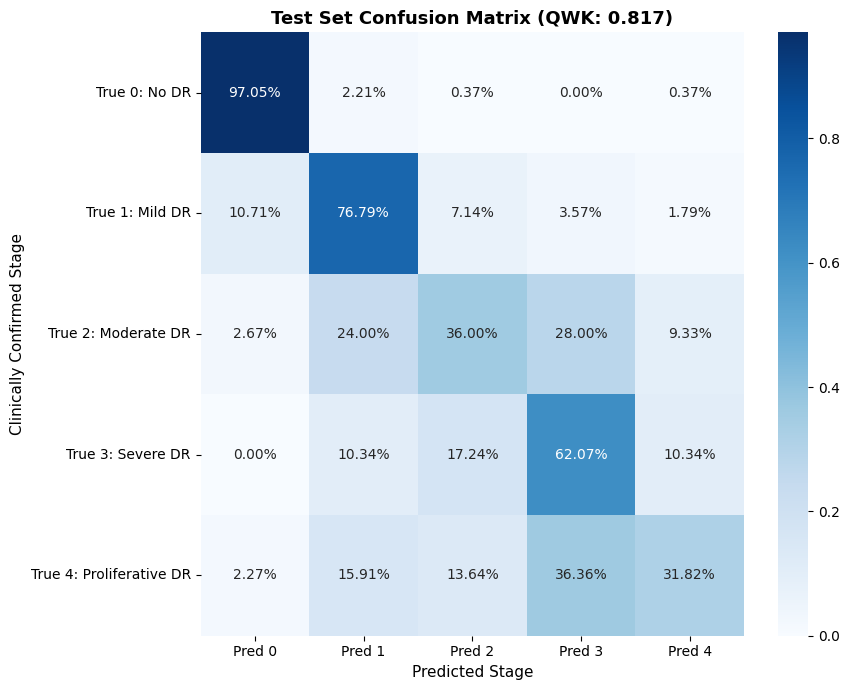

Saved figure5_confusion_matrix.png successfully.


In [14]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

# 1. Ensure the optimal checkpoint is loaded
model.load_state_dict(torch.load("best_retinopathy_model.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Detailed Classification Report
target_names = [f"Stage {i} ({class_names[i]})" for i in range(5)]
print("\n" + "="*60)
print("TEST SET CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# 3. Clinical Benchmark Metric: Quadratic Weighted Kappa (QWK)
qwk_score = cohen_kappa_score(y_true, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk_score:.4f}")
print("="*60)

# 4. Generate Figure 5: Normalized Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=[f"Pred {i}" for i in range(5)],
    yticklabels=[f"True {i}: {class_names[i]}" for i in range(5)],
    cbar=True
)
plt.title(f"Test Set Confusion Matrix (QWK: {qwk_score:.3f})", fontsize=13, weight='bold')
plt.xlabel("Predicted Stage", fontsize=11)
plt.ylabel("Clinically Confirmed Stage", fontsize=11)
plt.tight_layout()
plt.savefig("figure5_confusion_matrix.png", dpi=300)
plt.show()
print("Saved figure5_confusion_matrix.png successfully.")

**Implementing Grad Cam Diagnostic Heatmaps**

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


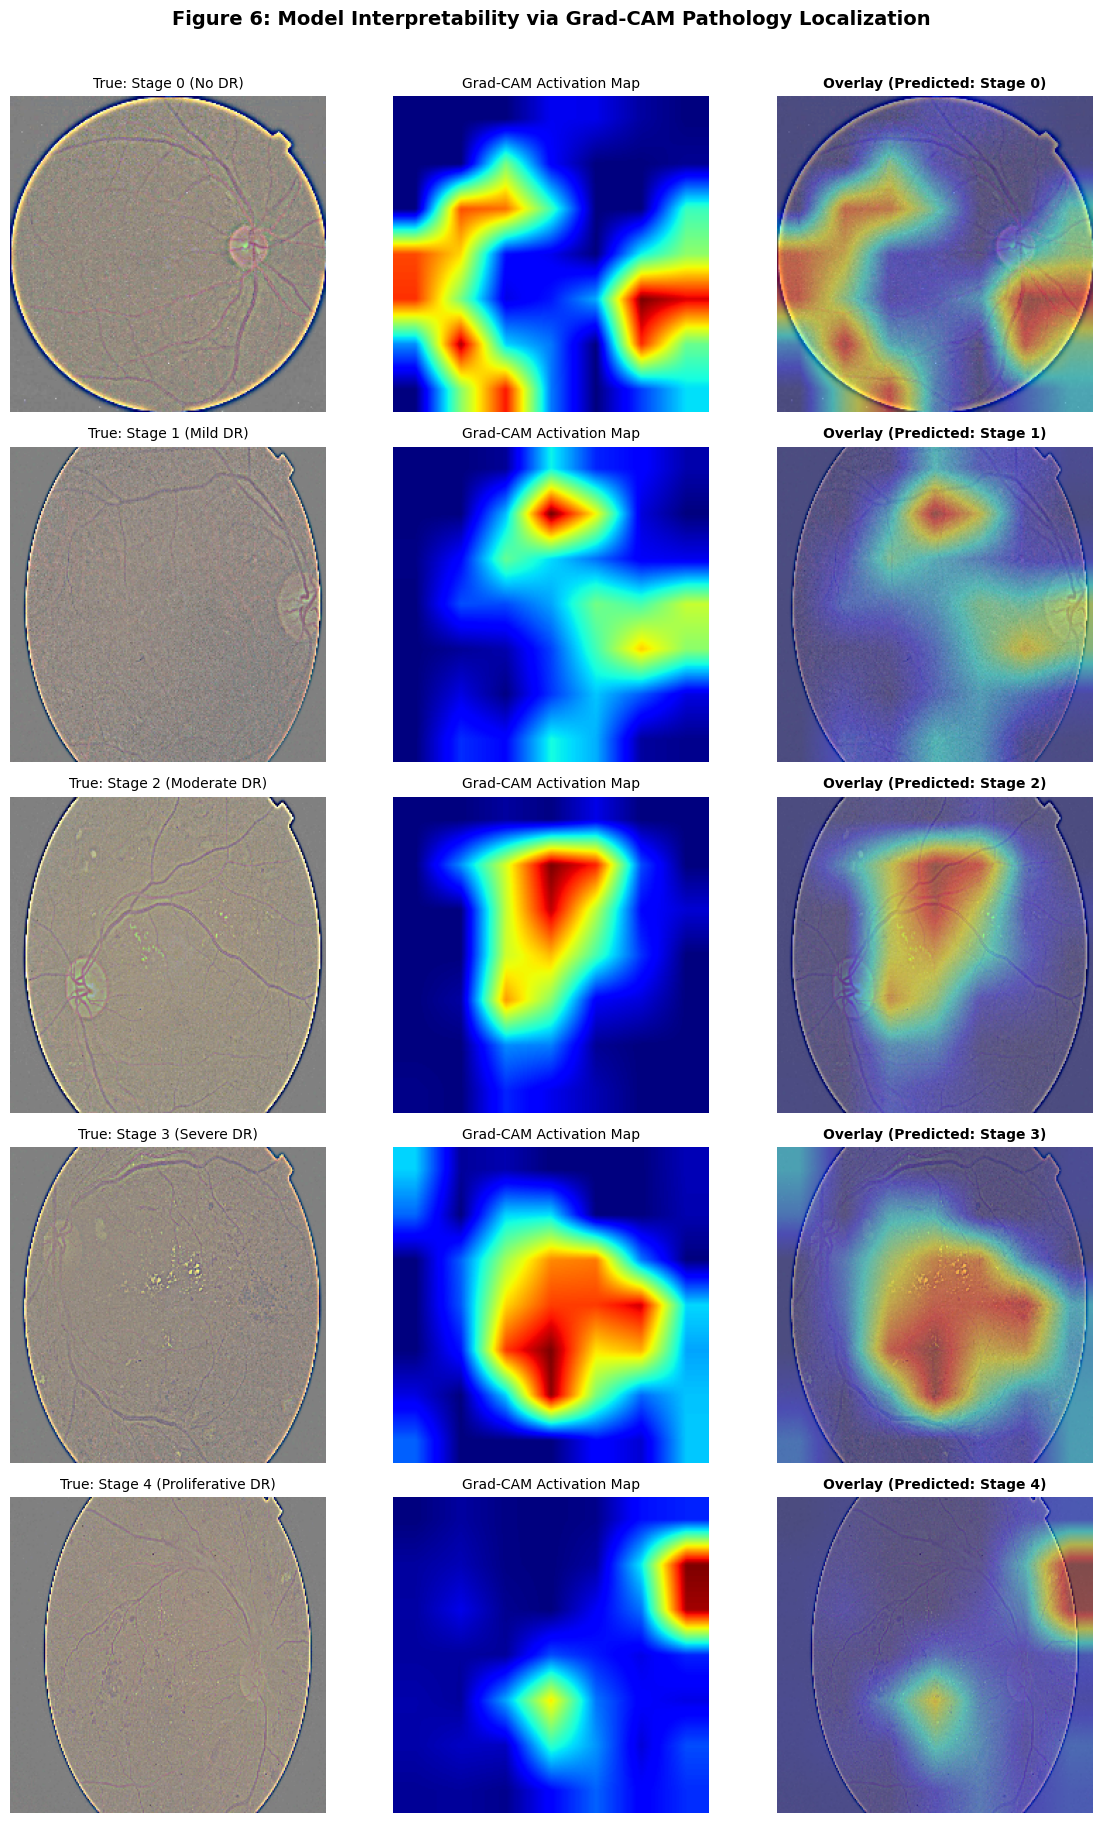

Saved figure6_gradcam_analysis.png successfully.


In [15]:
import cv2
import torch.nn.functional as F

class GradCAM:
    """Computes Gradient-weighted Class Activation Maps for EfficientNet."""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        # Global Average Pooling of gradients across feature map dimensions
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze()

        # Apply ReLU to retain features that positively correlate with the class
        cam = F.relu(cam)
        cam = cam.detach().cpu().numpy()

        # Normalize between 0 and 1
        cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)
        return cam, class_idx

# -------------------------------------------------------------
# Generate Figure 6: Explainability Visualizations
# -------------------------------------------------------------
grad_cam = GradCAM(model, model.features[-1])

fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for stage_idx in range(5):
    # Retrieve a sample from each stage in the test set
    test_sub = test_df[test_df['diagnosis'] == stage_idx]
    if len(test_sub) == 0:
        continue
    sample_row = test_sub.iloc[0]
    raw_img = Image.open(sample_row['file_path']).convert("RGB").resize((224, 224))

    # Prepare input tensor
    input_tensor = eval_transforms(raw_img).unsqueeze(0).to(device)

    # Generate heatmap
    heatmap, pred_class = grad_cam.generate_heatmap(input_tensor)

    # Process heatmap overlay
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    raw_np = np.array(raw_img)
    overlay = np.uint8(0.6 * raw_np + 0.4 * heatmap_colored)

    # Column 1: Original Fundus
    axes[stage_idx, 0].imshow(raw_np)
    axes[stage_idx, 0].set_title(f"True: Stage {stage_idx} ({class_names[stage_idx]})", fontsize=10)
    axes[stage_idx, 0].axis('off')

    # Column 2: Raw Grad-CAM Heatmap
    axes[stage_idx, 1].imshow(heatmap_resized, cmap='jet')
    axes[stage_idx, 1].set_title("Grad-CAM Activation Map", fontsize=10)
    axes[stage_idx, 1].axis('off')

    # Column 3: Diagnostic Overlay
    axes[stage_idx, 2].imshow(overlay)
    axes[stage_idx, 2].set_title(f"Overlay (Predicted: Stage {pred_class})", fontsize=10, weight='bold')
    axes[stage_idx, 2].axis('off')

plt.suptitle("Figure 6: Model Interpretability via Grad-CAM Pathology Localization", fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig("figure6_gradcam_analysis.png", dpi=300)
plt.show()
print("Saved figure6_gradcam_analysis.png successfully.")

**Export Deliverables**

In [16]:
import json

# Export model weights and label dictionary
torch.save(model.state_dict(), "final_retinopathy_model.pth")

config_metadata = {
    "architecture": "EfficientNet-B3",
    "num_classes": 5,
    "class_names": class_names,
    "input_resolution": [224, 224]
}

with open("model_metadata.json", "w") as f:
    json.dump(config_metadata, f, indent=4)

print("Export complete: final_retinopathy_model.pth and model_metadata.json ready for prototype deployment.")

Export complete: final_retinopathy_model.pth and model_metadata.json ready for prototype deployment.
